In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.8125
Confusion Matrix:
 [[13 15]
 [ 3 65]]
Report:
               precision    recall  f1-score   support

           0       0.81      0.46      0.59        28
           1       0.81      0.96      0.88        68

    accuracy                           0.81        96
   macro avg       0.81      0.71      0.73        96
weighted avg       0.81      0.81      0.79        96

Gender:  0.0110
Married:  0.0261
Dependents:  0.0259
Education:  0.0119
Self_Employed:  0.0085
ApplicantIncome:  0.1309
CoapplicantIncome:  0.0900
LoanAmount:  0.1545
Loan_Amount_Term:  0.0601
Credit_History:  0.4321
Property_Area:  0.0489


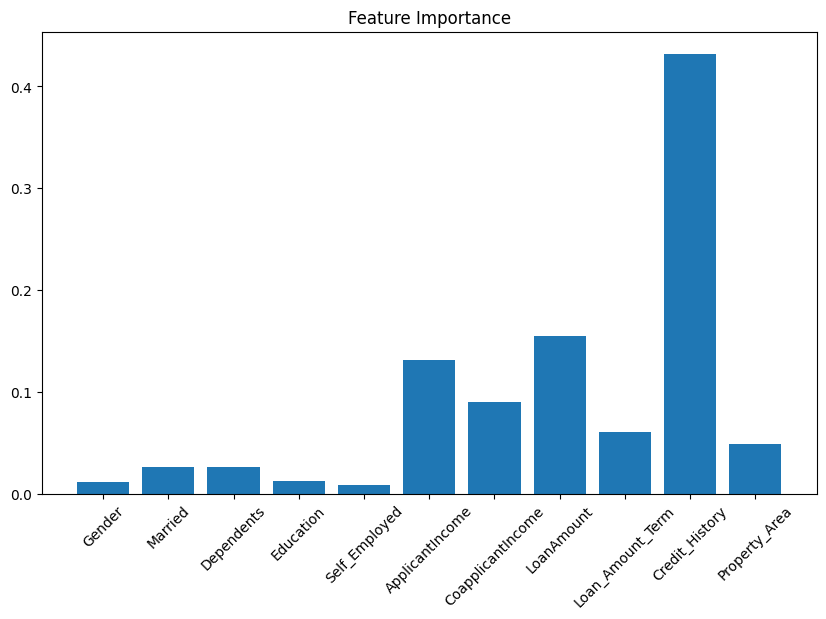

Prediction: 0


In [14]:
df = pd.read_csv("loan_dataset.csv")

# print(df.head())
# print(df.info())
# print(df.isnull().sum())
df = df.dropna()

df = df.drop('Loan_ID', axis=1)

df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

##handle missing value 
df.fillna(0, inplace=True)

##convert categorical variables to numeric using one hot encoding 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['Gender','Married', 'Education', 'Self_Employed', 'Property_Area']
for col in cols:
    df[col] = le.fit_transform(df[col])



df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,              # 3-fold cross validation
    scoring='precision',
    n_jobs=-1          # use all CPU cores
)

grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_


model = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced')

model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))

# ------------------------------------------------------------------------------------------------
importances = model.feature_importances_
for i, col in enumerate(X.columns):
    print(f"{col}: {importances[i]: .4f}")

plt.figure(figsize=(10, 6))
plt.bar(X.columns, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()



# test the model with new data 
new_data = pd.DataFrame([[1,1,0,1,0,5000,0,250,360,1,2]], columns = X.columns)
prediction = model.predict(new_data)
print("Prediction:", best_model.predict(new_data)[0])
      

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy: 0.8125
Confusion Matrix:
 [[12 16]
 [ 2 66]]
Report:
               precision    recall  f1-score   support

           0       0.86      0.43      0.57        28
           1       0.80      0.97      0.88        68

    accuracy                           0.81        96
   macro avg       0.83      0.70      0.73        96
weighted avg       0.82      0.81      0.79        96

Loan_Status
1    332
0    148
Name: count, dtype: int64
Credit_History: 0.5028
TotalIncome: 0.2214
LoanAmount: 0.2106
Loan_Amount_Term: 0.0651


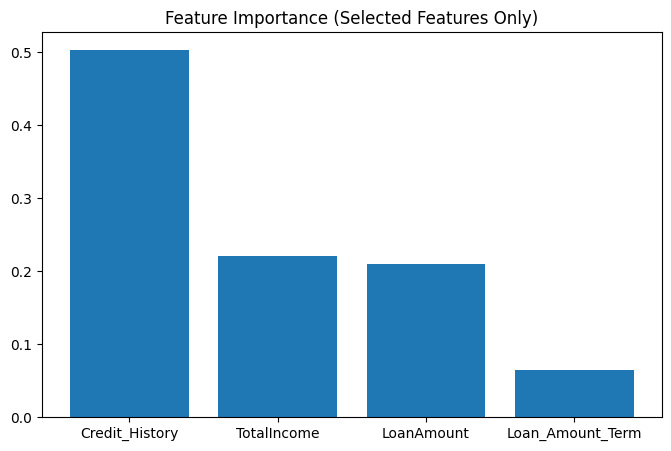

Prediction: 1


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("loan_dataset.csv")

# Drop missing values
df = df.dropna()

# Drop unnecessary column
df = df.drop('Loan_ID', axis=1)

# Convert target variable
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Convert Dependents
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# 🔥 Create TotalIncome feature
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# ✅ Select ONLY important features
features = ['Credit_History', 'TotalIncome', 'LoanAmount', 'Loan_Amount_Term']
X = df[features]
y = df['Loan_Status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# GridSearchCV for tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Best model
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))
print(df['Loan_Status'].value_counts())

# Feature Importance
importances = best_model.feature_importances_

for i, col in enumerate(X.columns):
    print(f"{col}: {importances[i]:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.bar(X.columns, importances)
plt.title("Feature Importance (Selected Features Only)")
plt.show()

# ✅ Test with new data
# Format: Credit_History, TotalIncome, LoanAmount, Loan_Amount_Term
new_data = pd.DataFrame([[1, 5000, 250, 360]], columns=features)

prediction = best_model.predict(new_data)

print("Prediction:", prediction[0])